# Batch Normalization on CIFAR-10

In this notebook we implement batch normalization, which is an opimization method useful for deep feed-forward neural networks, such as deep CNNs. Here we implement it on a toy-model of fully-connected (dense) layers, and toy-data (CIFAR-10).

In addition to Batch Normalization, we demonstrate how to implement early stopping, saving a checkpoint model, and use Keras logging for Tensorboard.

The main takeaways from this notebook are to know how to implement in Keras:
1. Batch Normalization
2. Early Stopping
3. Saving Checkpoints
4. Default Keras Logs into Tensorboard

Based on the [notebook](https://github.com/ageron/handson-ml3/blob/main/11_training_deep_neural_networks.ipynb) of Geron, chapter 11, exercise 8.
Presented here in accordance with the Apache 2.0 license.

In [1]:
import tensorflow as tf

## Get the Data
CIFAR-10 dataset is composed of 60,000 32 × 32–pixel color images (50,000 for training, 10,000 for testing) with 10 classes (for students: what is the difference between CIFAR-10 and MNIST in that sense?).

We get the data from tf.keras.datasets (similar to how we did for MNIST). This means that we get numpy array back.

As seen in the [dataset description](https://keras.io/api/datasets/cifar10/), the 10 classes are:

Label |	Description
--- | ---
0 |	airplane
1 |	automobile
2 |	bird
3 |	cat
4 |	deer
5 |	dog
6 |	frog
7 |	horse
8 |	ship
9 |	truck

In [3]:
cifar10 = tf.keras.datasets.cifar10.load_data()
(X_train_full, y_train_full), (X_test, y_test) = cifar10

# TODO: for the students: how many images are there in the training and the validation sets?
# TODO: for the students: what does 'x' and 'y' stand for?
X_train = X_train_full[5000:]
y_train = y_train_full[5000:]
X_valid = X_train_full[:5000]
y_valid = y_train_full[:5000]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


## Data Exploration

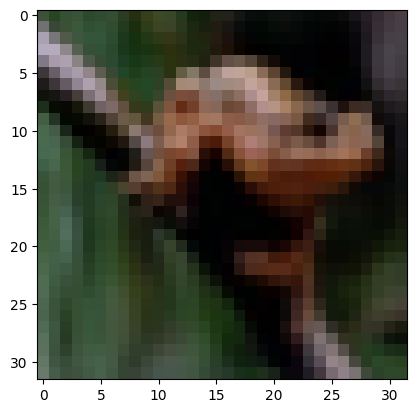

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [6]:
print(y_train[0])

[6]


In [ ]:
# TODO: for the students: which additional data explorations would you do?

## Define the Base Model
Here we build a DNN with 20 hidden layers of 100 neurons each.
That's too many, but it's the point of this exercise, because it allows us to use some of the optimization techniques we learned.

In [10]:
# TODO: for the students: can you add comments to each line of code below explaining what it does and why?

# ?
tf.random.set_seed(42)

# ?
model = tf.keras.Sequential()
# ?
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3]))
# ?
for _ in range(20):
    # ?
    model.add(tf.keras.layers.Dense(100,
                                    # ?
                                    activation="swish",
                                    # ?
                                    kernel_initializer="he_normal"))
# ?
model.add(tf.keras.layers.Dense(10, activation="softmax"))

C:\Users\wayne\anaconda3\envs\deeplearning-env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Define the Loss Function, Optimizer and Metrics

In [12]:
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-5)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

## Define Callbacks for Early Stopping, Checkpoints, and Logging

In [17]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("cifar10_model.keras", save_best_only=True)

run_index = 1 # increment every time you train the model
run_logdir = f"./runs/cifar10_logs/run_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

## Traing the Model
Before start running the training, initialize Tensorboard, such that you can view the training as it progresses.

In [19]:
model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks, verbose=2)

Epoch 1/100
1407/1407 - 29s - 20ms/step - accuracy: 0.1721 - loss: 4.2357 - val_accuracy: 0.2160 - val_loss: 2.2079
Epoch 2/100
1407/1407 - 14s - 10ms/step - accuracy: 0.2379 - loss: 2.1011 - val_accuracy: 0.2556 - val_loss: 2.0680
Epoch 3/100
1407/1407 - 15s - 10ms/step - accuracy: 0.2770 - loss: 1.9831 - val_accuracy: 0.2950 - val_loss: 1.9654
Epoch 4/100
1407/1407 - 15s - 11ms/step - accuracy: 0.3064 - loss: 1.9086 - val_accuracy: 0.3244 - val_loss: 1.9132
Epoch 5/100
1407/1407 - 16s - 11ms/step - accuracy: 0.3339 - loss: 1.8438 - val_accuracy: 0.3432 - val_loss: 1.8196
Epoch 6/100
1407/1407 - 15s - 11ms/step - accuracy: 0.3531 - loss: 1.7973 - val_accuracy: 0.3596 - val_loss: 1.7776
Epoch 7/100
1407/1407 - 15s - 11ms/step - accuracy: 0.3693 - loss: 1.7603 - val_accuracy: 0.3698 - val_loss: 1.7583
Epoch 8/100
1407/1407 - 14s - 10ms/step - accuracy: 0.3825 - loss: 1.7196 - val_accuracy: 0.3914 - val_loss: 1.7147
Epoch 9/100
1407/1407 - 15s - 11ms/step - accuracy: 0.3915 - loss: 1.690

### Batch Normalization

In [24]:
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[32, 32, 3])) #32*32*3 RGB
for _ in range(20):
    model.add(tf.keras.layers.Dense(100, kernel_initializer="he_normal"))
    model.add(tf.keras.layers.BatchNormalization())  # Adding batch normalization
    model.add(tf.keras.layers.Activation("swish")) ####

model.add(tf.keras.layers.Dense(10, activation="softmax"))

optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20,
                                                     restore_best_weights=True)
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("cifar10_bn_model.keras",
                                                         save_best_only=True)
run_index = 1 # increment every time you train the model
run_logdir = f"cifar10_logs/run_bn_{run_index:03d}"
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)
callbacks = [early_stopping_cb, model_checkpoint_cb, tensorboard_cb]

model.fit(X_train, y_train, epochs=100,
          validation_data=(X_valid, y_valid),
          callbacks=callbacks)

model.evaluate(X_valid, y_valid)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 19ms/step - accuracy: 0.1846 - loss: 2.2170 - val_accuracy: 0.3296 - val_loss: 1.8598
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.3311 - loss: 1.8339 - val_accuracy: 0.3832 - val_loss: 1.7281
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.3928 - loss: 1.6953 - val_accuracy: 0.3528 - val_loss: 1.8936
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.4281 - loss: 1.6076 - val_accuracy: 0.3816 - val_loss: 1.7272
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.4595 - loss: 1.5241 - val_accuracy: 0.4050 - val_loss: 1.6758
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.4867 - loss: 1.4540 - val_accuracy: 0.3990 - val_loss: 1.6942
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5094 - loss: 1.3913 - val_accuracy: 0.3868 - val_loss: 1.7762
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 

[1.6757904291152954, 0.4050000011920929]

In [26]:
# 啟用 TensorBoard 擴充功能
%load_ext tensorboard

# 使用對應 logdir 啟動 TensorBoard
%tensorboard --logdir=cifar10_logs
